# Market Basket Analysis Using Apriori

## CMPE 255 — Assignment 1, Part 2

This notebook replicates a market basket analysis experiment using
association rule mining.

The goal is to identify products that are frequently purchased together
and discover meaningful relationships between items.

The workflow includes:

1. Dataset Understanding
2. Transaction Preparation
3. Basket Encoding
4. Frequent Itemset Mining
5. Apriori Algorithm
6. Association Rules
7. Support, Confidence, and Lift Analysis
8. Rule Interpretation
9. Result Visualization
10. Final Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Dataset Understanding

The first step is to load the grocery transaction dataset and inspect its
structure before creating market baskets.

In [2]:
df = pd.read_csv("../data/Groceries_dataset.csv")

df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


### Initial Data Understanding

The dataset contains 38,765 grocery purchase records and three columns:

- `Member_number`
- `Date`
- `itemDescription`

There are no missing values.

The dataset contains 759 exact duplicate rows. Since this experiment focuses on
whether an item appears in a transaction rather than how many units were purchased,
exact duplicate records will be removed before basket encoding.

A transaction will be defined as all items purchased by the same member on the
same date.

Therefore:

`Member_number + Date → one transaction`

In [3]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

# Remove exact duplicate item records
df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Duplicates removed:", len(df) - len(df_clean))

Original rows: 38765
Rows after removing duplicates: 38006
Duplicates removed: 759


In [4]:
df_clean["TransactionID"] = (
    df_clean["Member_number"].astype(str)
    + "_"
    + df_clean["Date"].dt.strftime("%Y-%m-%d")
)

df_clean.head()

,Member_number,Date,itemDescription,TransactionID
0,1808,2015-07-21,tropical fruit,1808_2015-07-21
1,2552,2015-01-05,whole milk,2552_2015-01-05
2,2300,2015-09-19,pip fruit,2300_2015-09-19
3,1187,2015-12-12,other vegetables,1187_2015-12-12
4,3037,2015-02-01,whole milk,3037_2015-02-01


In [5]:
print("Unique members:", df_clean["Member_number"].nunique())
print("Unique items:", df_clean["itemDescription"].nunique())
print("Unique transactions:", df_clean["TransactionID"].nunique())

items_per_transaction = (
    df_clean.groupby("TransactionID")["itemDescription"]
    .nunique()
)

print("\nItems per transaction:")
print(items_per_transaction.describe())

Unique members: 3898
Unique items: 167
Unique transactions: 14963

Items per transaction:
count    14963.000000
mean         2.539999
std          1.060993
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         10.000000
Name: itemDescription, dtype: float64


In [6]:
top_items = (
    df_clean["itemDescription"]
    .value_counts()
    .head(15)
)

top_items

itemDescription
whole milk          2363
other vegetables    1827
rolls/buns          1646
soda                1453
yogurt              1285
root vegetables     1041
tropical fruit      1014
bottled water        908
sausage              903
citrus fruit         795
pastry               774
pip fruit            734
shopping bags        712
canned beer          702
bottled beer         678
Name: count, dtype: int64

### Transaction Analysis

After removing exact duplicate records, purchases were grouped by
`Member_number` and `Date` to represent individual transactions.

The cleaned dataset contains:

- 3,898 unique members
- 167 unique grocery items
- 14,963 unique transactions

A transaction contains an average of approximately 2.54 unique items.
The median transaction contains 2 items, while the largest transaction
contains 10 items.

The most frequently purchased products include:

- whole milk
- other vegetables
- rolls/buns
- soda
- yogurt

These frequent products are good candidates for appearing in frequent
itemsets, but purchase frequency alone does not indicate that two products
have a meaningful association. Association rules will therefore be evaluated
using support, confidence, and lift.

## 2. Basket Encoding

The transaction records must be converted into a basket matrix before applying
the Apriori algorithm.

Each row represents one transaction and each column represents one product.

A value of:

- `True` means that the product appeared in the transaction
- `False` means that the product did not appear

In [7]:
basket = pd.crosstab(
    df_clean["TransactionID"],
    df_clean["itemDescription"]
).astype(bool)

print("Basket shape:", basket.shape)

basket.head()

Basket shape: (14963, 167)


itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
TransactionID,,,,,,,,,,,,,,,,,,,,,
1000_2014-06-24,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1000_2015-03-15,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1000_2015-05-27,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1000_2015-07-24,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1000_2015-11-25,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
from mlxtend.frequent_patterns import apriori, association_rules

In [9]:
frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True,
    max_len=3
)

frequent_itemsets["length"] = (
    frequent_itemsets["itemsets"]
    .apply(len)
)

frequent_itemsets = frequent_itemsets.sort_values(
    "support",
    ascending=False
)

print("Number of frequent itemsets:", len(frequent_itemsets))

frequent_itemsets.head(20)

Number of frequent itemsets: 69


,support,itemsets,length
62,0.157923,frozenset({whole milk}),1
40,0.122101,frozenset({other vegetables}),1
46,0.110005,frozenset({rolls/buns}),1
52,0.097106,frozenset({soda}),1
63,0.085879,frozenset({yogurt}),1
47,0.069572,frozenset({root vegetables}),1
57,0.067767,frozenset({tropical fruit}),1
5,0.060683,frozenset({bottled water}),1
49,0.060349,frozenset({sausage}),1
15,0.053131,frozenset({citrus fruit}),1


In [10]:
multi_itemsets = frequent_itemsets[
    frequent_itemsets["length"] >= 2
].copy()

print("Frequent itemsets with 2 or more items:", len(multi_itemsets))

multi_itemsets.head(20)

Frequent itemsets with 2 or more items: 5


,support,itemsets,length
65,0.014837,"frozenset({whole milk, other vegetables})",2
66,0.013968,"frozenset({whole milk, rolls/buns})",2
67,0.011629,"frozenset({whole milk, soda})",2
68,0.011161,"frozenset({whole milk, yogurt})",2
64,0.010559,"frozenset({rolls/buns, other vegetables})",2


## 3. Association Rule Mining

Frequent itemsets show which products appear frequently, but they do not
directly describe directional relationships between products.

Association rules will therefore be generated and evaluated using:

- Support
- Confidence
- Lift

A rule such as:

`A → B`

means that transactions containing product A are evaluated to determine how
often product B also appears.

In [11]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.05
)

print("Number of association rules:", len(rules))

rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    "lift",
    ascending=False
).head(20)

Number of association rules: 10


,antecedents,consequents,support,confidence,lift
6,frozenset({whole milk}),frozenset({yogurt}),0.011161,0.070673,0.822940
7,frozenset({yogurt}),frozenset({whole milk}),0.011161,0.129961,0.822940
2,frozenset({whole milk}),frozenset({rolls/buns}),0.013968,0.088447,0.804028
3,frozenset({rolls/buns}),frozenset({whole milk}),0.013968,0.126974,0.804028
9,frozenset({other vegetables}),frozenset({rolls/buns}),0.010559,0.086481,0.786154
8,frozenset({rolls/buns}),frozenset({other vegetables}),0.010559,0.095990,0.786154
1,frozenset({other vegetables}),frozenset({whole milk}),0.014837,0.121511,0.769430
0,frozenset({whole milk}),frozenset({other vegetables}),0.014837,0.093948,0.769430
4,frozenset({whole milk}),frozenset({soda}),0.011629,0.073635,0.758296
5,frozenset({soda}),frozenset({whole milk}),0.011629,0.119752,0.758296


### Expanding the Rule Search

Using a minimum support of 0.01 produced only a small number of association
rules, and the strongest rules had lift values below 1.

This suggests that the current threshold may be too restrictive for this
dataset.

To explore less frequent but potentially more meaningful product
relationships, the minimum support will be reduced to 0.005.

In [12]:
frequent_itemsets_005 = apriori(
    basket,
    min_support=0.005,
    use_colnames=True,
    max_len=3
)

frequent_itemsets_005["length"] = (
    frequent_itemsets_005["itemsets"]
    .apply(len)
)

print(
    "Number of frequent itemsets:",
    len(frequent_itemsets_005)
)

Number of frequent itemsets: 126


In [13]:
rules_005 = association_rules(
    frequent_itemsets_005,
    metric="confidence",
    min_threshold=0.05
)

print("Number of association rules:", len(rules_005))

rules_005[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    "lift",
    ascending=False
).head(20)

Number of association rules: 57


,antecedents,consequents,support,confidence,lift
6,frozenset({frankfurter}),frozenset({other vegetables}),0.005146,0.136283,1.116150
43,frozenset({sausage}),frozenset({yogurt}),0.005748,0.095238,1.108986
42,frozenset({yogurt}),frozenset({sausage}),0.005748,0.066926,1.108986
38,frozenset({sausage}),frozenset({soda}),0.005948,0.098560,1.014975
39,frozenset({soda}),frozenset({sausage}),0.005948,0.061253,1.014975
0,frozenset({bottled beer}),frozenset({whole milk}),0.007151,0.157817,0.999330
41,frozenset({sausage}),frozenset({whole milk}),0.008955,0.148394,0.939663
40,frozenset({whole milk}),frozenset({sausage}),0.008955,0.056708,0.939663
8,frozenset({newspapers}),frozenset({whole milk}),0.005614,0.144330,0.913926
5,frozenset({domestic eggs}),frozenset({whole milk}),0.005280,0.142342,0.901341


In [14]:
positive_rules = (
    rules_005[
        rules_005["lift"] > 1
    ]
    .sort_values(
        ["lift", "confidence"],
        ascending=False
    )
)

print(
    "Rules with lift > 1:",
    len(positive_rules)
)

positive_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(20)

Rules with lift > 1: 5


,antecedents,consequents,support,confidence,lift
6,frozenset({frankfurter}),frozenset({other vegetables}),0.005146,0.136283,1.116150
43,frozenset({sausage}),frozenset({yogurt}),0.005748,0.095238,1.108986
42,frozenset({yogurt}),frozenset({sausage}),0.005748,0.066926,1.108986
38,frozenset({sausage}),frozenset({soda}),0.005948,0.098560,1.014975
39,frozenset({soda}),frozenset({sausage}),0.005948,0.061253,1.014975


### Association Rule Interpretation

After lowering the minimum support threshold from 0.01 to 0.005, five
association rules with lift greater than 1 were identified.

The strongest observed rule was:

- `frankfurter → other vegetables`
- Support: approximately 0.0051
- Confidence: approximately 0.136
- Lift: approximately 1.116

A lift greater than 1 indicates that the antecedent and consequent appear
together more often than would be expected if they were independent.

For example, transactions containing frankfurter were approximately 11.6%
more likely to also contain other vegetables than expected under independence.

Other positive associations included:

- `sausage → yogurt` with lift approximately 1.109
- `yogurt → sausage` with lift approximately 1.109
- `sausage → soda` with lift approximately 1.015
- `soda → sausage` with lift approximately 1.015

However, these rules have relatively low support and lift values only slightly
above 1. Therefore, they should be interpreted as modest associations rather
than strong purchasing relationships.

This result also demonstrates why frequently purchased items alone are not
enough to identify useful market-basket relationships. Support, confidence,
and lift need to be considered together.

In [15]:
final_rules = positive_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

final_rules["antecedents"] = final_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

final_rules["consequents"] = final_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

final_rules = final_rules.reset_index(drop=True)

final_rules

,antecedents,consequents,support,confidence,lift
0,frankfurter,other vegetables,0.005146,0.136283,1.116150
1,sausage,yogurt,0.005748,0.095238,1.108986
2,yogurt,sausage,0.005748,0.066926,1.108986
3,sausage,soda,0.005948,0.098560,1.014975
4,soda,sausage,0.005948,0.061253,1.014975


In [16]:
fi_save = frequent_itemsets_005.copy()

fi_save["itemsets"] = fi_save["itemsets"].apply(
    lambda x: ", ".join(sorted(x))
)

fi_save = fi_save.sort_values(
    ["support", "itemsets"],
    ascending=[False, True]
).reset_index(drop=True)

fi_save.to_csv(
    "../results/frequent_itemsets.csv",
    index=False
)

print("Frequent itemsets saved.")

Frequent itemsets saved.


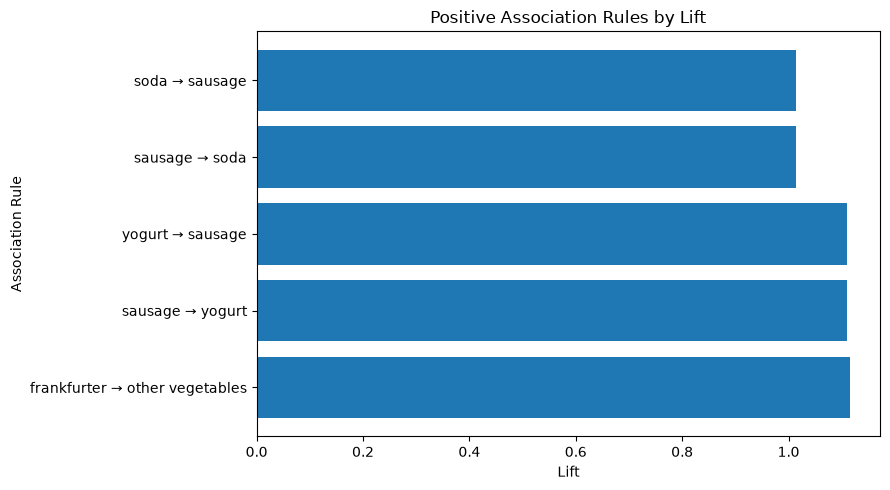

In [17]:
plt.figure(figsize=(9, 5))

rule_labels = (
    final_rules["antecedents"]
    + " → "
    + final_rules["consequents"]
)

plt.barh(
    rule_labels,
    final_rules["lift"]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Positive Association Rules by Lift")

plt.tight_layout()

plt.savefig(
    "../figures/association_rules_lift.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 4. Final Conclusion

This experiment used the Apriori algorithm and association rule mining to
analyze grocery purchasing patterns.

The dataset contained:

- 3,898 unique members
- 167 unique grocery items
- 14,963 unique transactions

A transaction was defined as all items purchased by the same member on the
same date.

The basket data was converted into a Boolean transaction matrix and analyzed
using the Apriori algorithm.

With an initial minimum support threshold of 0.01, 69 frequent itemsets were
identified. However, the resulting association rules had lift values below 1,
indicating that the observed product combinations were not stronger than
expected under independence.

To explore less frequent combinations, the minimum support threshold was
reduced to 0.005.

This produced five association rules with lift greater than 1.

The strongest observed rule was:

- `frankfurter → other vegetables`
- Support: approximately 0.0051
- Confidence: approximately 0.136
- Lift: approximately 1.116

Additional positive associations included:

- `sausage → yogurt`
- `yogurt → sausage`
- `sausage → soda`
- `soda → sausage`

These rules had relatively low support and lift values only slightly above 1,
so they should be interpreted as modest associations rather than strong
purchasing relationships.

The experiment demonstrates that frequently purchased products are not
necessarily strongly associated with one another.

Support, confidence, and lift must be considered together when interpreting
market basket relationships.

It also demonstrates how adjusting the support threshold can reveal less
frequent patterns that would otherwise be excluded, while requiring careful
interpretation to avoid overstating weak associations.